# 04 — Model Training

Train 5 models on the clean 209-feature dataset and save to `models/`:

| # | Model | Approach |
|---|---|---|
| 1 | **Logistic Regression** | Classical baseline, needs scaling |
| 2 | **Random Forest** | Stable ensemble |
| 3 | **LightGBM** | SOTA gradient boosting |
| 4 | **CatBoost** | SOTA gradient boosting |
| 5 | **EBM** | Interpretable boosting (InterpretML) |

**Workflow:** Stratified 5-Fold CV → сравнительная таблица → обучение на всех данных → сохранение в `models/`

**Метрика:** AUC-ROC (OOF)  |  **Дисбаланс:** `scale_pos_weight` / `class_weight` / `auto_class_weights`

> **Следующие шаги:** `05_evaluation.ipynb` → `06_interpretation.ipynb`

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.base import clone

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src import config
from src.models import get_models
from src.training import (
    load_data, cross_validate_model, train_final_model, save_model, load_model,
)
from src.plotting import (
    plot_roc_curves, plot_pr_curves,
    plot_cv_score_distribution, plot_metrics_comparison,
    plot_fold_heatmap, plot_metrics_radar, build_comparison_table,
)

print('Ready.')

Ready.


In [2]:
test_clean_path = config.PROCESSED_FILES.get('final_test_clean')
if test_clean_path is None or not Path(test_clean_path).exists():
    print(f'[WARNING] final_test_clean.parquet не найден: {test_clean_path}')
    print('Запусти секцию 9 ноутбука 03_build_dataset.ipynb для его создания.')
else:
    size_mb = Path(test_clean_path).stat().st_size / 1024 / 1024
    print(f'[OK] final_test_clean.parquet найден ({size_mb:.1f} MB)')

[OK] final_test_clean.parquet найден (16.2 MB)


## 1. Load Data

In [3]:
X, y = load_data()

SCALE_POS_WEIGHT = (y == 0).sum() / (y == 1).sum()
print(f'\nscale_pos_weight = {SCALE_POS_WEIGHT:.4f}')
print(f'Features: {X.columns.tolist()[:5]} ... ({X.shape[1]} total)')

Loaded: 307,511 rows × 209 features
Default rate: 8.07%  |  scale_pos_weight: 11.3872

scale_pos_weight = 11.3872
Features: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE'] ... (209 total)


## 2. Define Models

In [4]:
models = get_models(
    scale_pos_weight=SCALE_POS_WEIGHT,
    random_state=config.RANDOM_SEED,
)

for name, model in models.items():
    print(f'  {name:10s} → {type(model).__name__}')

  logreg     → LogisticRegression
  rf         → RandomForestClassifier
  lgbm       → LGBMClassifier
  catboost   → CatBoostClassifier
  ebm        → ExplainableBoostingClassifier


## 3. Cross-Validation

**Stratified 5-Fold CV** with out-of-fold (OOF) predictions.  
- LogReg & RF: `StandardScaler` applied per fold (fit on train only)  
- LightGBM / CatBoost / EBM: no scaling needed  

> ⚠️ **Slow cell** — expected runtime:  
> LogReg ~3 min · RF ~15 min · LightGBM ~10 min · CatBoost ~20 min · EBM ~30 min

In [5]:
results = {}

for name, model in models.items():
    print(f'\n── {name.upper()} ──')
    results[name] = cross_validate_model(
        model, X, y,
        model_name=name,
        n_splits=5,
        random_state=config.RANDOM_SEED,
    )


── LOGREG ──
  Fold 1: AUC=0.7645  F1=0.2768  Prec=0.1727  Rec=0.6977  Acc=0.7057
  Fold 2: AUC=0.7740  F1=0.2785  Prec=0.1733  Rec=0.7082  Acc=0.7037
  Fold 3: AUC=0.7732  F1=0.2767  Prec=0.1720  Rec=0.7069  Acc=0.7016
  Fold 4: AUC=0.7753  F1=0.2793  Prec=0.1741  Rec=0.7055  Acc=0.7060
  Fold 5: AUC=0.7662  F1=0.2725  Prec=0.1700  Rec=0.6858  Acc=0.7044
  → Mean AUC: 0.7706 ± 0.0044  |  F1: 0.2768  Prec: 0.1724  Rec: 0.7008  Acc: 0.7043

── RF ──
  Fold 1: AUC=0.7569  F1=0.2295  Prec=0.3458  Rec=0.1718  Acc=0.9069
  Fold 2: AUC=0.7590  F1=0.2295  Prec=0.3417  Rec=0.1728  Acc=0.9063
  Fold 3: AUC=0.7544  F1=0.2256  Prec=0.3320  Rec=0.1708  Acc=0.9053
  Fold 4: AUC=0.7621  F1=0.2246  Prec=0.3366  Rec=0.1686  Acc=0.9061
  Fold 5: AUC=0.7542  F1=0.2141  Prec=0.3215  Rec=0.1605  Acc=0.9049
  → Mean AUC: 0.7573 ± 0.0030  |  F1: 0.2247  Prec: 0.3355  Rec: 0.1689  Acc: 0.9059

── LGBM ──
  Fold 1: AUC=0.7736  F1=0.3175  Prec=0.2291  Rec=0.5170  Acc=0.8205
  Fold 2: AUC=0.7826  F1=0.3241  Pr

## 4. Comparison Table

In [6]:
comparison = build_comparison_table(results)

comparison.style \
    .background_gradient(subset=['ROC-AUC (mean)'], cmap='RdYlGn') \
    .background_gradient(subset=['ROC-AUC (std)'],  cmap='RdYlGn_r') \
    .background_gradient(subset=['F1 class-1'],     cmap='RdYlGn') \
    .background_gradient(subset=['F1 weighted'],    cmap='RdYlGn') \
    .background_gradient(subset=['Precision'],      cmap='RdYlGn') \
    .background_gradient(subset=['Recall'],         cmap='RdYlGn') \
    .background_gradient(subset=['Accuracy'],       cmap='RdYlGn') \
    .format(precision=4)

,Model,ROC-AUC (mean),ROC-AUC (std),F1 class-1,F1 weighted,Precision,Recall,Accuracy,AUC Fold 1,AUC Fold 2,AUC Fold 3,AUC Fold 4,AUC Fold 5
0,CATBOOST,0.7860,0.0034,0.3024,0.8041,0.1953,0.6696,0.7506,0.7825,0.7903,0.7840,0.7900,0.7831
1,EBM,0.7853,0.0038,0.0884,0.8879,0.5474,0.0481,0.9200,0.7802,0.7912,0.7842,0.7879,0.7833
2,LGBM,0.7782,0.0033,0.3213,0.8508,0.2319,0.5231,0.8216,0.7736,0.7826,0.7769,0.7814,0.7767
3,LOGREG,0.7706,0.0044,0.2768,0.7708,0.1724,0.7008,0.7043,0.7645,0.7740,0.7732,0.7753,0.7662
4,RF,0.7573,0.0030,0.2247,0.8914,0.3355,0.1689,0.9059,0.7569,0.7590,0.7544,0.7621,0.7542


## 5. ROC Curves

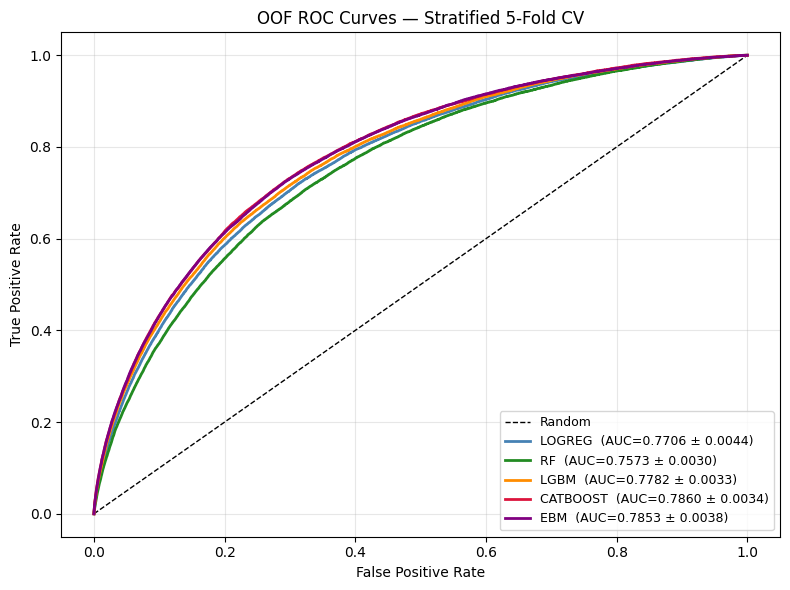

Saved → reports/roc_curves.png


In [7]:
fig = plot_roc_curves(
    results,
    save_path=ROOT / 'reports' / 'roc_curves.png',
)
plt.show()
print('Saved → reports/roc_curves.png')

## 6. CV Score Distribution

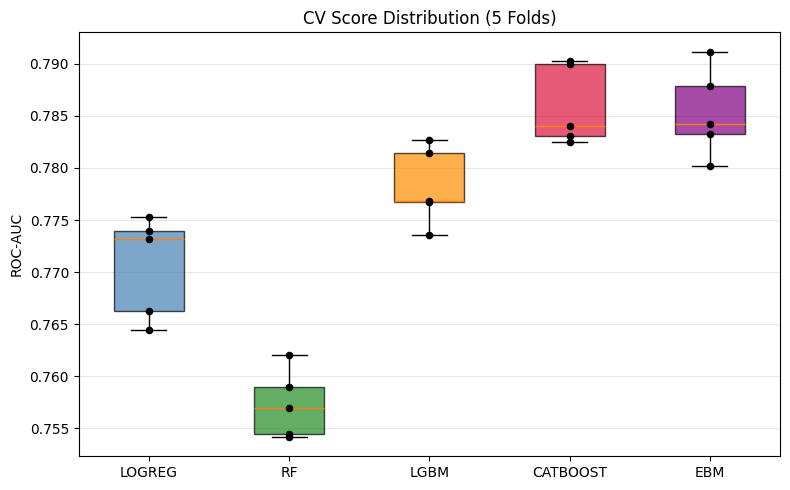

Saved → reports/cv_score_distribution.png


In [8]:
fig = plot_cv_score_distribution(
    results,
    save_path=ROOT / 'reports' / 'cv_score_distribution.png',
)
plt.show()
print('Saved → reports/cv_score_distribution.png')

## 7. Precision-Recall Curves

PR-кривые особенно информативны при дисбалансе классов: они показывают trade-off между точностью и полнотой. Пунктирная линия — baseline (доля дефолтов ≈ 8%).

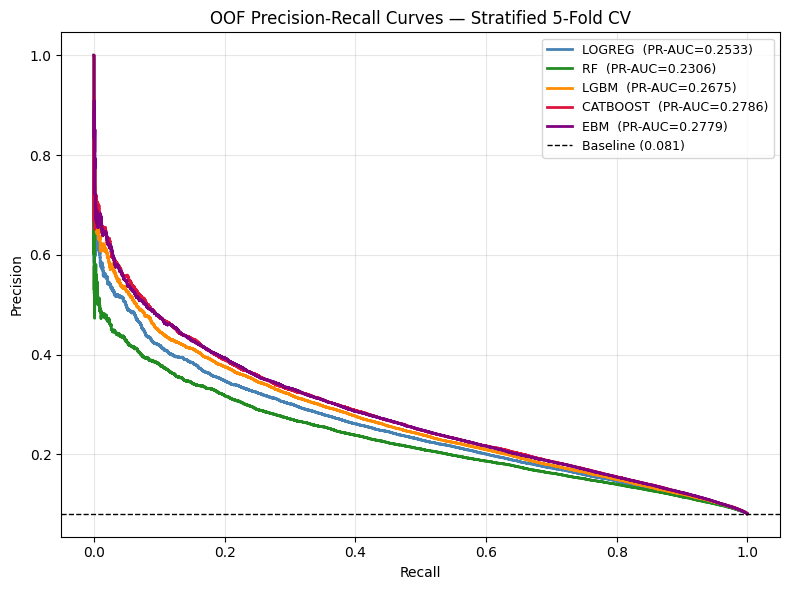

Saved → reports/pr_curves.png


In [9]:
fig = plot_pr_curves(
    results,
    save_path=ROOT / 'reports' / 'pr_curves.png',
)
plt.show()
print('Saved → reports/pr_curves.png')

## 8. Grouped Bar Chart — All Metrics

Сравнительная диаграмма всех 6 метрик для каждой модели. Порог классификации = 0.5.  
> **Напоминание**: Accuracy намеренно завышена из-за дисбаланса классов — её следует читать вместе с Recall.

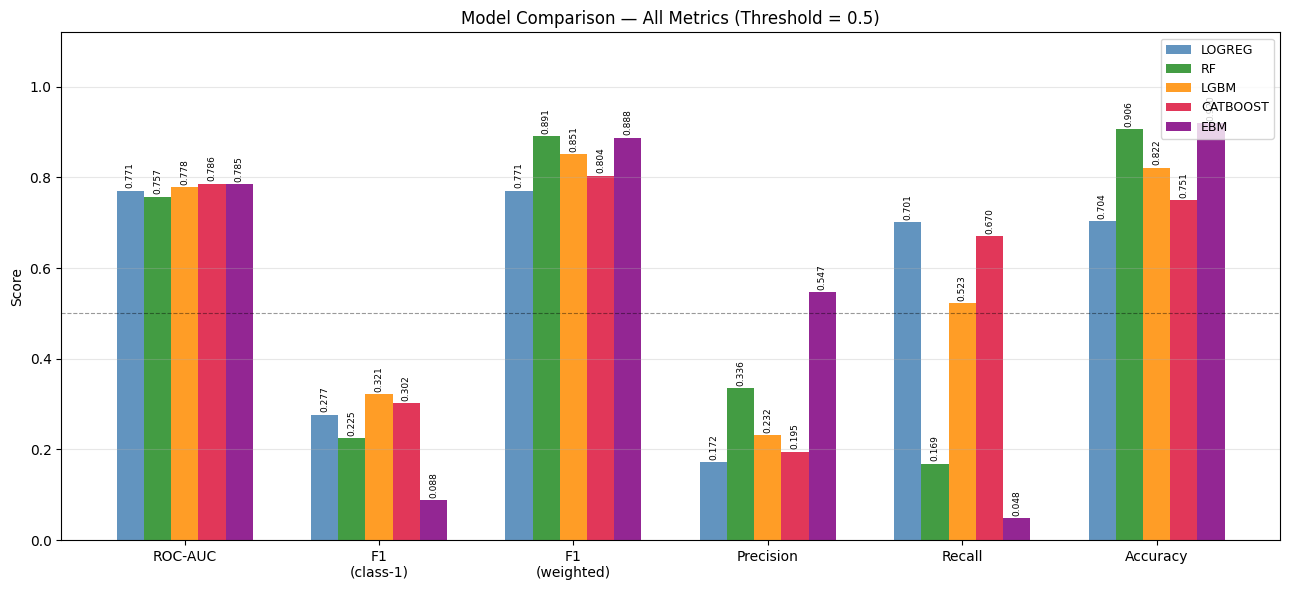

Saved → reports/metrics_comparison.png


In [10]:
fig = plot_metrics_comparison(
    results,
    save_path=ROOT / 'reports' / 'metrics_comparison.png',
)
plt.show()
print('Saved → reports/metrics_comparison.png')

## 9. Per-Fold AUC Heatmap

Показывает стабильность модели по фолдам. Идеальная модель — одинаковые значения по строке. Правый столбец (μ) — среднее по фолдам.

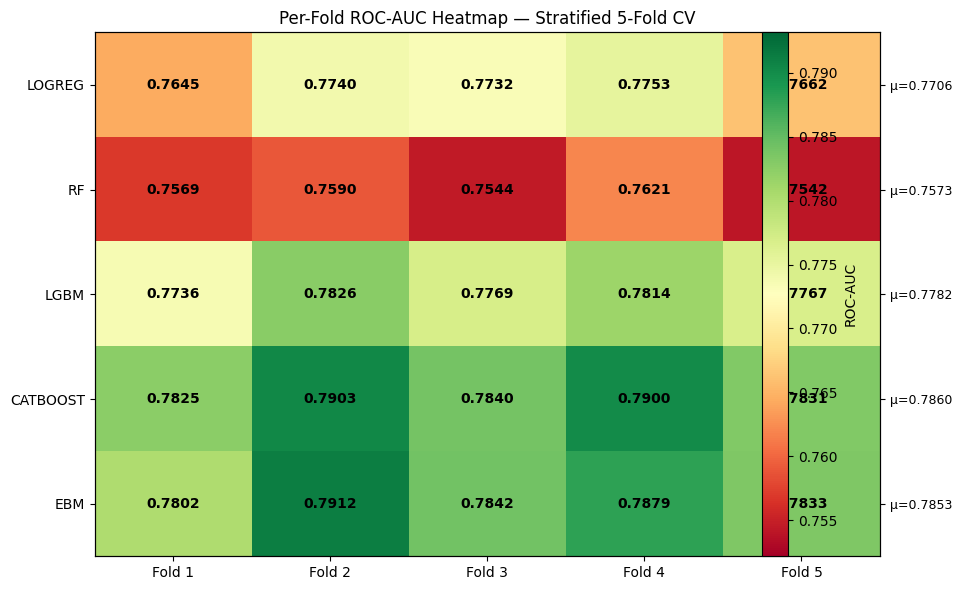

Saved → reports/fold_heatmap.png


In [11]:
fig = plot_fold_heatmap(
    results,
    save_path=ROOT / 'reports' / 'fold_heatmap.png',
)
plt.show()
print('Saved → reports/fold_heatmap.png')

## 10. Radar Chart — Комплексный профиль моделей

Spider-диаграмма позволяет одним взглядом оценить сильные и слабые стороны каждой модели по всем метрикам одновременно. Большая площадь фигуры = более сильная модель в целом.

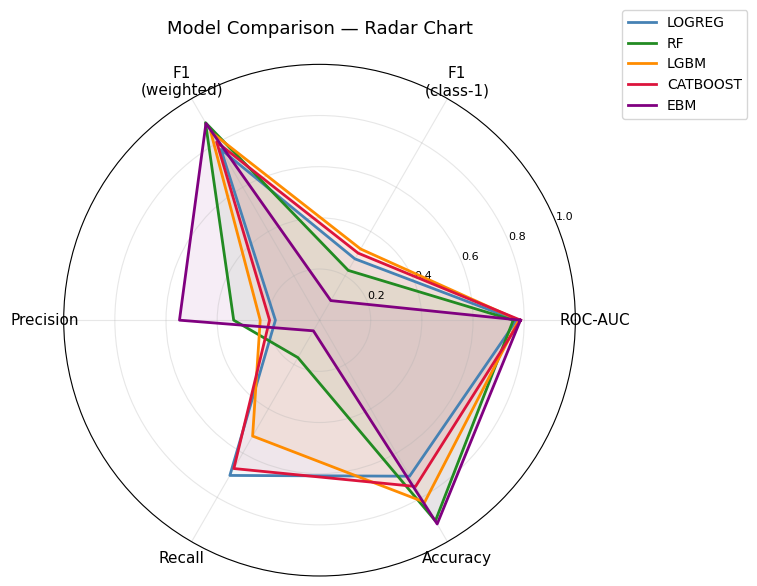

Saved → reports/metrics_radar.png


In [12]:
fig = plot_metrics_radar(
    results,
    save_path=ROOT / 'reports' / 'metrics_radar.png',
)
plt.show()
print('Saved → reports/metrics_radar.png')

## 11. Train Final Models on Full Data

CV gave us an honest AUC estimate. Now retrain each model on all 307,511 rows  
to get the strongest possible weights for inference.

In [13]:
final_models = {}

for name, model in models.items():
    print(f'Training final {name}...')
    final_models[name] = train_final_model(
        clone(model), X, y, model_name=name
    )
    save_model(final_models[name], name)

Training final logreg...
  Saved logreg → /Users/aitursun/Developer/University/credit-default-prediction/models/logreg.joblib  (7 KB)
Training final rf...
  Saved rf → /Users/aitursun/Developer/University/credit-default-prediction/models/rf.joblib  (914762 KB)
Training final lgbm...
  Saved lgbm → /Users/aitursun/Developer/University/credit-default-prediction/models/lgbm.joblib  (6795 KB)
Training final catboost...
  Saved catboost → /Users/aitursun/Developer/University/credit-default-prediction/models/catboost.joblib  (1114 KB)
Training final ebm...
  Saved ebm → /Users/aitursun/Developer/University/credit-default-prediction/models/ebm.joblib  (2885 KB)


## 12. Model Loading Verification

In [14]:
print('Round-trip load & predict — all 5 models (first 5 rows):')
sample = X.head(5).to_numpy(dtype='float32')

for name in final_models:
    m = load_model(name)
    inp = m._scaler.transform(sample) if hasattr(m, '_scaler') else sample
    preds = m.predict_proba(inp)[:, 1]
    status = 'OK' if (config.MODELS_DIR / f'{name}.joblib').exists() else 'MISSING'
    print(f'  [{status}] {name:10s}: {preds.round(4)}')

Round-trip load & predict — all 5 models (first 5 rows):
  [OK] logreg    : [0.9227 0.0889 0.2824 0.327  0.5232]
  [OK] rf        : [0.7687 0.0824 0.0868 0.1172 0.1784]
  [OK] lgbm      : [0.9074 0.0753 0.1805 0.1575 0.3182]
  [OK] catboost  : [0.8349 0.1577 0.2783 0.2006 0.4343]
  [OK] ebm       : [0.3325 0.0134 0.0323 0.041  0.0672]


## 13. Summary

In [15]:
print('=' * 60)
print('TRAINING SUMMARY')
print('=' * 60)
print(comparison.to_string(index=False))

best = comparison.iloc[0]
print(f'\nBest model : {best["Model"]}')
print(f'ROC-AUC    : {best["ROC-AUC (mean)"]:.4f} ± {best["ROC-AUC (std)"]:.4f}')
print(f'F1 class-1 : {best["F1 class-1"]:.4f}')
print(f'Precision  : {best["Precision"]:.4f}')
print(f'Recall     : {best["Recall"]:.4f}')
print(f'Accuracy   : {best["Accuracy"]:.4f}')

print('\nСохранённые модели:')
for name in final_models:
    p = config.MODELS_DIR / f'{name}.joblib'
    if p.exists():
        print(f'  {p.name:25s}  {p.stat().st_size / 1024:.0f} KB')

print('\nСохранённые CV-отчёты:')
cv_artifacts = [
    'reports/roc_curves.png',
    'reports/pr_curves.png',
    'reports/cv_score_distribution.png',
    'reports/metrics_comparison.png',
    'reports/fold_heatmap.png',
    'reports/metrics_radar.png',
]
for a in cv_artifacts:
    p = ROOT / a
    status = 'OK' if p.exists() else 'MISSING'
    print(f'  [{status}] {a}')

TRAINING SUMMARY
   Model  ROC-AUC (mean)  ROC-AUC (std)  F1 class-1  F1 weighted  Precision  Recall  Accuracy  AUC Fold 1  AUC Fold 2  AUC Fold 3  AUC Fold 4  AUC Fold 5
CATBOOST          0.7860         0.0034      0.3024       0.8041     0.1953  0.6696    0.7506      0.7825      0.7903      0.7840      0.7900      0.7831
     EBM          0.7853         0.0038      0.0884       0.8879     0.5474  0.0481    0.9200      0.7802      0.7912      0.7842      0.7879      0.7833
    LGBM          0.7782         0.0033      0.3213       0.8508     0.2319  0.5231    0.8216      0.7736      0.7826      0.7769      0.7814      0.7767
  LOGREG          0.7706         0.0044      0.2768       0.7708     0.1724  0.7008    0.7043      0.7645      0.7740      0.7732      0.7753      0.7662
      RF          0.7573         0.0030      0.2247       0.8914     0.3355  0.1689    0.9059      0.7569      0.7590      0.7544      0.7621      0.7542

Best model : CATBOOST
ROC-AUC    : 0.7860 ± 0.0034
F1 clas

---

## Next Steps

Модели сохранены в `models/`. Запусти следующие ноутбуки по порядку:

1. **`05_evaluation.ipynb`** — оптимальный порог, confusion matrix, калибровка,
   кривые Лифта/Gain, бизнес-стоимость, анализ ошибок по сегментам
2. **`06_interpretation.ipynb`** — feature importances (встроенные), SHAP для всех
   моделей, waterfall plots, EBM global/local объяснения
